# Midterm Projects: AI 5/6G Communications and O-RAN Networks

**Student:** Oscar Cortez  
**Instructor:** Tawanda Chiyangwa  
**Course:** ITAI-4370  
**Date:** July 13, 2026

## Project Overview
This notebook completes all three midterm questions. It demonstrates discrete-event network simulation with SimPy, agent-based adaptive routing with Mesa, and machine-learning-based traffic prediction with scikit-learn. Fixed random seeds are used so the results can be reproduced.

In [1]:
# Run this cell first. It installs SimPy and Mesa only if they are missing.
import sys, subprocess, importlib.util

for package in ["simpy", "mesa"]:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import random
import simpy
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import deque
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 4370
random.seed(SEED)
np.random.seed(SEED)

print("SimPy version:", simpy.__version__)
print("Mesa version:", mesa.__version__)

/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SimPy version: 4.1.2
Mesa version: 3.5.1


# Question 1: Network Traffic Simulation Using SimPy

## Objective
A three-router chain is simulated using discrete events. Packets are generated at random intervals, wait in each router queue, experience a processing delay, and then move to the next router. The model records end-to-end packet latency and network throughput.

## Network Design

`Packet Generator → Router 1 → Router 2 → Router 3 → Destination`

Each router is modeled as a SimPy resource with one processing channel. This means packets may wait in a queue when a router is busy.

In [2]:
class Router:
    """A router that queues, processes, and forwards packets."""
    def __init__(self, env, name, processing_delay, next_router=None):
        self.env = env
        self.name = name
        self.processing_delay = processing_delay
        self.next_router = next_router
        self.resource = simpy.Resource(env, capacity=1)
        self.processed_packets = 0

    def receive(self, packet):
        arrival_to_router = self.env.now
        with self.resource.request() as request:
            yield request
            queue_wait = self.env.now - arrival_to_router
            packet["queue_wait"] += queue_wait

            delay = random.uniform(*self.processing_delay)
            yield self.env.timeout(delay)
            packet["processing_time"] += delay
            self.processed_packets += 1

        if self.next_router is not None:
            yield self.env.process(self.next_router.receive(packet))
        else:
            packet["completion_time"] = self.env.now
            packet["latency"] = packet["completion_time"] - packet["creation_time"]
            completed_packets.append(packet)


def packet_generator(env, first_router, number_of_packets=120, mean_interarrival=1.25):
    """Generate packets using exponentially distributed interarrival times."""
    for packet_id in range(number_of_packets):
        packet = {
            "packet_id": packet_id,
            "creation_time": env.now,
            "queue_wait": 0.0,
            "processing_time": 0.0,
        }
        env.process(first_router.receive(packet))
        interarrival = random.expovariate(1 / mean_interarrival)
        yield env.timeout(interarrival)


random.seed(SEED)
completed_packets = []
env = simpy.Environment()

router3 = Router(env, "Router 3", (0.35, 0.65))
router2 = Router(env, "Router 2", (0.45, 0.80), next_router=router3)
router1 = Router(env, "Router 1", (0.30, 0.60), next_router=router2)

env.process(packet_generator(env, router1))
env.run()

q1_results = pd.DataFrame(completed_packets)
simulation_time = q1_results["completion_time"].max()
throughput = len(q1_results) / simulation_time

summary_q1 = pd.DataFrame({
    "Metric": ["Packets delivered", "Simulation time", "Average latency", "Median latency", "Maximum latency", "Throughput"],
    "Value": [
        len(q1_results), simulation_time, q1_results["latency"].mean(),
        q1_results["latency"].median(), q1_results["latency"].max(), throughput
    ],
    "Unit": ["packets", "time units", "time units", "time units", "time units", "packets/time unit"]
})
summary_q1.round(3)

,Metric,Value,Unit
0,Packets delivered,120.000,packets
1,Simulation time,187.151,time units
2,Average latency,1.669,time units
3,Median latency,1.621,time units
4,Maximum latency,2.452,time units
5,Throughput,0.641,packets/time unit


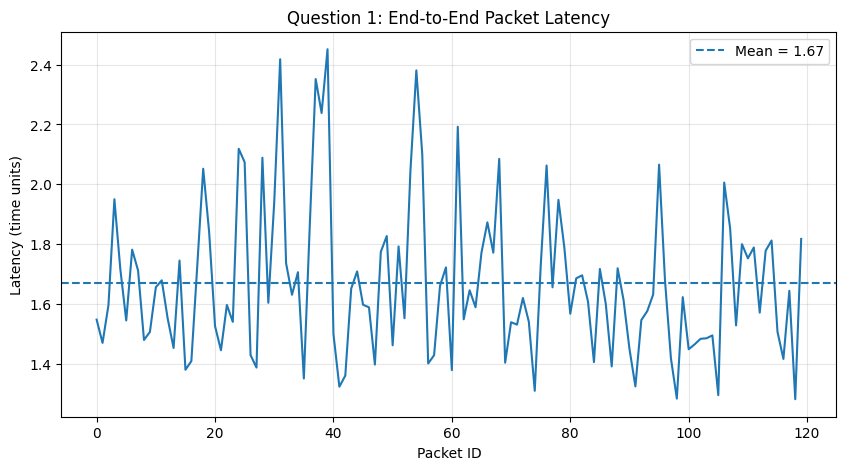

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(q1_results["packet_id"], q1_results["latency"], linewidth=1.5)
plt.axhline(q1_results["latency"].mean(), linestyle="--", label=f"Mean = {q1_results['latency'].mean():.2f}")
plt.title("Question 1: End-to-End Packet Latency")
plt.xlabel("Packet ID")
plt.ylabel("Latency (time units)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Question 1 Discussion
The simulation shows how packet latency includes both processing time and queue waiting time. When packets arrive faster than a router can process them, a queue forms and latency rises. Throughput is calculated as the number of successfully delivered packets divided by total simulation time. The fixed router chain provides a simple example of discrete-event network behavior and reveals how a bottleneck at one router can affect the entire path.

# Question 2: Agent-Based Network Modeling Using Mesa

## Objective
This model represents users and routers as autonomous agents. Users create packets, while routers process and forward them. An entry router monitors congestion on the main path. When the main router queue reaches a threshold, packets are rerouted through an alternate router.

## Topology

- Users send packets to **Entry Router R0**.
- R0 normally sends packets through **Main Router R1**.
- During congestion, R0 sends packets through **Alternate Router R2**.
- Both paths terminate at **Destination Router R3**.

A temporary traffic burst is introduced in the middle of the simulation to demonstrate congestion and recovery.

In [4]:
class UserAgent(mesa.Agent):
    def __init__(self, model, generation_probability):
        super().__init__(model)
        self.generation_probability = generation_probability

    def step(self):
        # Create more traffic during the planned burst interval.
        burst_multiplier = 2.4 if 35 <= self.model.time < 65 else 1.0
        probability = min(0.95, self.generation_probability * burst_multiplier)
        if self.random.random() < probability:
            packet = {
                "packet_id": self.model.next_packet_id,
                "created": self.model.time,
                "route": [],
            }
            self.model.next_packet_id += 1
            self.model.generated += 1
            self.model.entry_router.queue.append(packet)


class RouterAgent(mesa.Agent):
    def __init__(self, model, name, capacity, role):
        super().__init__(model)
        self.name = name
        self.capacity = capacity
        self.role = role
        self.queue = deque()

    def step(self):
        for _ in range(min(self.capacity, len(self.queue))):
            packet = self.queue.popleft()
            packet["route"].append(self.name)

            if self.role == "entry":
                if len(self.model.main_router.queue) >= self.model.congestion_threshold:
                    self.model.alternate_router.queue.append(packet)
                    self.model.rerouted += 1
                else:
                    self.model.main_router.queue.append(packet)
            elif self.role in ("main", "alternate"):
                self.model.destination_router.queue.append(packet)
            elif self.role == "destination":
                packet["delivered"] = self.model.time
                packet["latency"] = packet["delivered"] - packet["created"] + 1
                self.model.delivered_packets.append(packet)


class AdaptiveNetworkModel(mesa.Model):
    def __init__(self, num_users=12, seed=SEED):
        super().__init__(seed=seed)
        self.time = 0
        self.next_packet_id = 0
        self.generated = 0
        self.rerouted = 0
        self.delivered_packets = []
        self.congestion_threshold = 6

        self.entry_router = RouterAgent(self, "R0 Entry", capacity=5, role="entry")
        self.main_router = RouterAgent(self, "R1 Main", capacity=2, role="main")
        self.alternate_router = RouterAgent(self, "R2 Alternate", capacity=3, role="alternate")
        self.destination_router = RouterAgent(self, "R3 Destination", capacity=6, role="destination")
        self.routers = [self.entry_router, self.main_router, self.alternate_router, self.destination_router]

        self.users = [UserAgent(self, generation_probability=0.23) for _ in range(num_users)]
        self.history = []

    def step(self):
        # Users generate traffic first.
        for user in self.users:
            user.step()

        # Routers then process packets in network order.
        for router in self.routers:
            router.step()

        self.history.append({
            "time": self.time,
            "entry_queue": len(self.entry_router.queue),
            "main_queue": len(self.main_router.queue),
            "alternate_queue": len(self.alternate_router.queue),
            "destination_queue": len(self.destination_router.queue),
            "cumulative_generated": self.generated,
            "cumulative_delivered": len(self.delivered_packets),
            "cumulative_rerouted": self.rerouted,
        })
        self.time += 1


model = AdaptiveNetworkModel()
for _ in range(110):
    model.step()

q2_history = pd.DataFrame(model.history)
q2_packets = pd.DataFrame(model.delivered_packets)

summary_q2 = pd.DataFrame({
    "Metric": ["Packets generated", "Packets delivered", "Packets rerouted", "Rerouting percentage", "Average delivered latency", "Maximum main queue"],
    "Value": [
        model.generated,
        len(model.delivered_packets),
        model.rerouted,
        100 * model.rerouted / model.generated,
        q2_packets["latency"].mean(),
        q2_history["main_queue"].max(),
    ]
})
summary_q2.round(2)

/opt/pyvenv/lib/python3.13/site-packages/mesa/mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


,Metric,Value
0,Packets generated,206.00
1,Packets delivered,203.00
2,Packets rerouted,93.00
3,Rerouting percentage,45.15
4,Average delivered latency,5.28
5,Maximum main queue,4.00


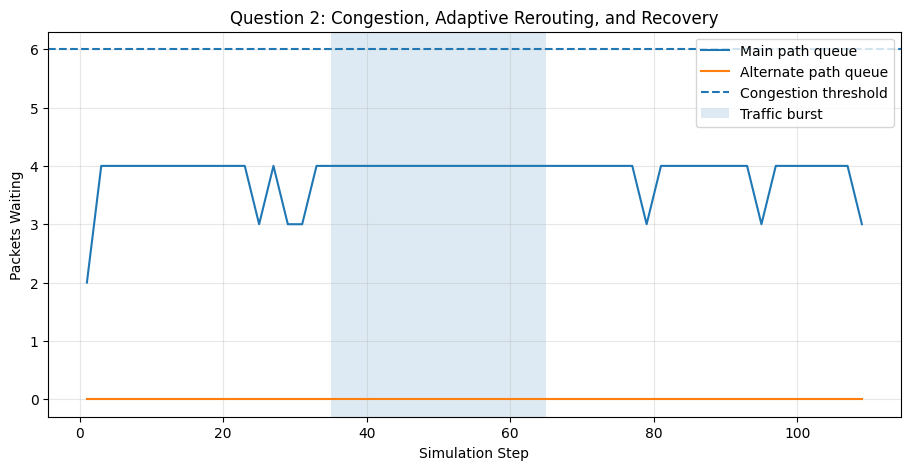

In [5]:
plt.figure(figsize=(11, 5))
plt.plot(q2_history["time"], q2_history["main_queue"], label="Main path queue")
plt.plot(q2_history["time"], q2_history["alternate_queue"], label="Alternate path queue")
plt.axhline(model.congestion_threshold, linestyle="--", label="Congestion threshold")
plt.axvspan(35, 65, alpha=0.15, label="Traffic burst")
plt.title("Question 2: Congestion, Adaptive Rerouting, and Recovery")
plt.xlabel("Simulation Step")
plt.ylabel("Packets Waiting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

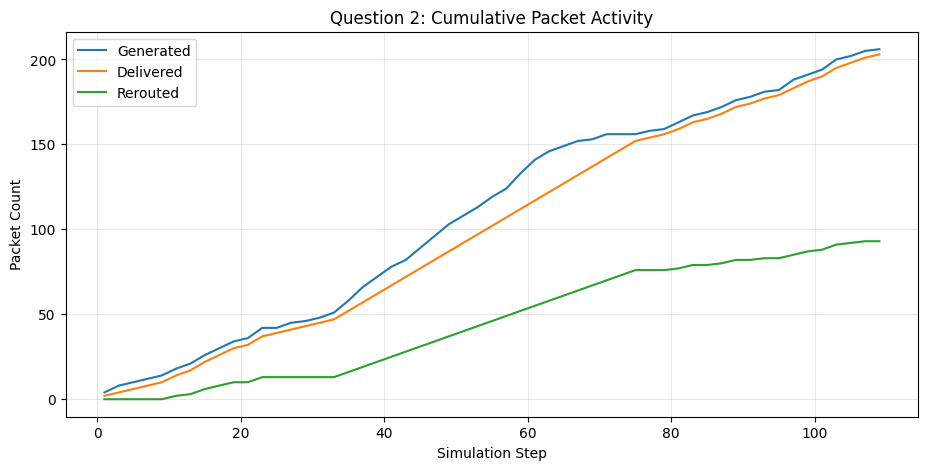

In [6]:
plt.figure(figsize=(11, 5))
plt.plot(q2_history["time"], q2_history["cumulative_generated"], label="Generated")
plt.plot(q2_history["time"], q2_history["cumulative_delivered"], label="Delivered")
plt.plot(q2_history["time"], q2_history["cumulative_rerouted"], label="Rerouted")
plt.title("Question 2: Cumulative Packet Activity")
plt.xlabel("Simulation Step")
plt.ylabel("Packet Count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Question 2 Discussion
The model demonstrates adaptive network behavior. Under normal load, packets use the main route. During the traffic burst, the main queue grows and crosses the congestion threshold. The entry router then redirects packets to the alternate route. As the burst ends, the queues decrease and the network returns toward normal operation. This behavior illustrates how agent-based modeling can represent autonomous routing decisions, congestion dynamics, and recovery.

# Question 3: Predictive Optimization Using Machine Learning

## Objective
Simulated network traffic is used to train a regression model that predicts traffic one time step into the future. The predicted traffic level is then converted into a routing-control decision.

## Machine-Learning Workflow
1. Generate realistic traffic using a daily pattern, trend, bursts, and random noise.
2. Create lag and rolling-average features.
3. Train a `RandomForestRegressor` on the earlier observations.
4. Test the model on later observations without shuffling, preserving time order.
5. Evaluate predictions using MAE, RMSE, and R².
6. Apply predicted traffic to dynamic routing decisions.

In [7]:
np.random.seed(SEED)
periods = 720
hour = np.arange(periods) % 24
trend = np.linspace(0, 18, periods)
daily_cycle = 38 + 22 * np.sin(2 * np.pi * (hour - 7) / 24)
noise = np.random.normal(0, 5, periods)

traffic = daily_cycle + trend + noise
for start, strength in [(150, 35), (330, 45), (540, 40)]:
    traffic[start:start+18] += np.linspace(strength, 5, 18)
traffic = np.clip(traffic, 5, None)

traffic_df = pd.DataFrame({"time": np.arange(periods), "hour": hour, "traffic": traffic})
traffic_df["lag_1"] = traffic_df["traffic"].shift(1)
traffic_df["lag_2"] = traffic_df["traffic"].shift(2)
traffic_df["lag_3"] = traffic_df["traffic"].shift(3)
traffic_df["rolling_mean_6"] = traffic_df["traffic"].shift(1).rolling(6).mean()
traffic_df["hour_sin"] = np.sin(2 * np.pi * traffic_df["hour"] / 24)
traffic_df["hour_cos"] = np.cos(2 * np.pi * traffic_df["hour"] / 24)
traffic_df["target_next_traffic"] = traffic_df["traffic"].shift(-1)
traffic_df = traffic_df.dropna().reset_index(drop=True)

features = ["lag_1", "lag_2", "lag_3", "rolling_mean_6", "hour_sin", "hour_cos"]
split_index = int(len(traffic_df) * 0.80)
train_df = traffic_df.iloc[:split_index]
test_df = traffic_df.iloc[split_index:]

X_train, y_train = train_df[features], train_df["target_next_traffic"]
X_test, y_test = test_df[features], test_df["target_next_traffic"]

model_ml = RandomForestRegressor(
    n_estimators=250,
    max_depth=12,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)
model_ml.fit(X_train, y_train)
predictions = model_ml.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

metrics_q3 = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)", "R-squared (R²)"],
    "Value": [mae, rmse, r2]
})
metrics_q3.round(3)

,Metric,Value
0,Mean Absolute Error (MAE),5.247
1,Root Mean Squared Error (RMSE),6.558
2,R-squared (R²),0.834


In [8]:
optimization_results = test_df[["time", "traffic", "target_next_traffic"]].copy()
optimization_results["predicted_next_traffic"] = predictions

low_threshold = np.percentile(y_train, 40)
high_threshold = np.percentile(y_train, 75)

def routing_action(predicted_traffic):
    if predicted_traffic < low_threshold:
        return "Normal route"
    elif predicted_traffic < high_threshold:
        return "Load balance across routes"
    return "Use alternate route / add capacity"

optimization_results["routing_decision"] = optimization_results["predicted_next_traffic"].apply(routing_action)
optimization_results.head(12).round(2)

,time,traffic,target_next_traffic,predicted_next_traffic,routing_decision
570,576,22.76,32.82,27.85,Normal route
571,577,32.82,25.86,24.63,Normal route
572,578,25.86,28.34,26.52,Normal route
573,579,28.34,42.19,32.66,Normal route
574,580,42.19,43.01,37.10,Normal route
575,581,43.01,46.23,45.53,Load balance across routes
576,582,46.23,52.46,51.53,Load balance across routes
577,583,52.46,61.27,57.58,Load balance across routes
578,584,61.27,65.15,60.95,Load balance across routes
579,585,65.15,65.41,65.25,Use alternate route / add capacity


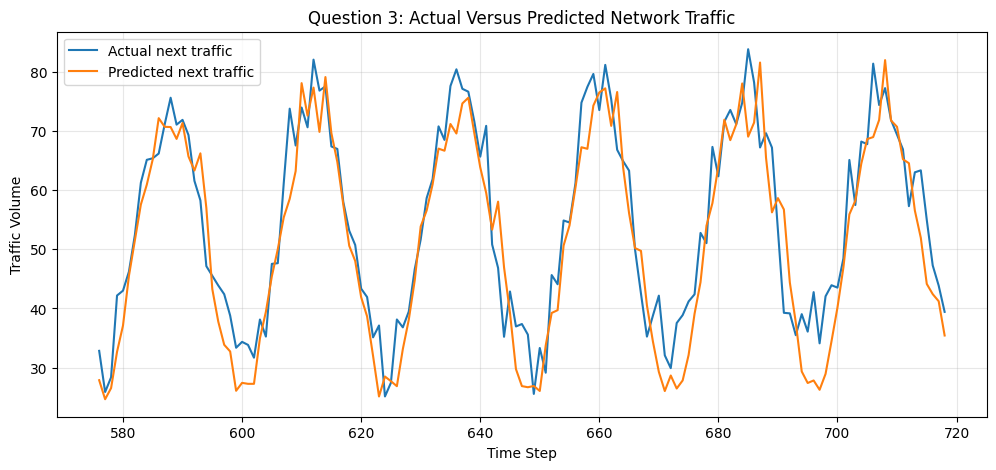

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(optimization_results["time"], optimization_results["target_next_traffic"], label="Actual next traffic")
plt.plot(optimization_results["time"], optimization_results["predicted_next_traffic"], label="Predicted next traffic")
plt.title("Question 3: Actual Versus Predicted Network Traffic")
plt.xlabel("Time Step")
plt.ylabel("Traffic Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
decision_counts = optimization_results["routing_decision"].value_counts().rename_axis("Routing Decision").reset_index(name="Number of Time Steps")
decision_counts

,Routing Decision,Number of Time Steps
0,Use alternate route / add capacity,51
1,Normal route,49
2,Load balance across routes,43


In [11]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model_ml.feature_importances_
}).sort_values("Importance", ascending=False)
feature_importance.round(3)

,Feature,Importance
5,hour_cos,0.681
0,lag_1,0.157
3,rolling_mean_6,0.065
1,lag_2,0.050
2,lag_3,0.024
4,hour_sin,0.024


## Question 3 Discussion
The regression model predicts near-future traffic from recent traffic values, a rolling average, and time-of-day features. MAE and RMSE describe the typical prediction error, while R² shows how much variation in future traffic is explained by the model. The routing policy converts predictions into practical actions. Low predicted traffic keeps the normal route, moderate traffic activates load balancing, and high predicted traffic triggers an alternate route or additional capacity. This is a simplified example of predictive self-optimization that could support intelligent O-RAN control decisions.

# Overall Conclusion
The three projects demonstrate complementary approaches to intelligent network management. SimPy models packet timing and queue delays as discrete events. Mesa models autonomous users and routers that respond to congestion. Scikit-learn adds predictive control by estimating future traffic before congestion becomes severe. Together, these methods show how simulation and AI can support adaptive, low-latency, and self-optimizing 5G/6G and O-RAN networks.

## References
- SimPy Documentation. *Discrete-event simulation for Python.*
- Mesa Documentation. *Agent-based modeling in Python.*
- Scikit-learn Documentation. *RandomForestRegressor and regression metrics.*